# LLM expert persona eval analysis

## 🛢️ Data preparation

- **Prompt versions:** multiple prompt versions have been used, but this notebook will only analyse data from the current prompt version.
- **Parse failures:** the program used to obtain the results does not save questions that exhaust all of the LLM retry attempts but does for those that produce a response from the LLM that can't be parsed. The program has the option to retry previous parse failures when doing new runs, meaning total parse failures and unique parse failures may be different. Also, sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed in this case.

In [1]:
import pandas as pd
from IPython.display import Markdown, display

df = pd.read_json('results.jsonl', lines=True)

# prompt version
current_prompt_version = 'question_v2'
current_prompt_df = df[df['prompt']==current_prompt_version]

print(f'\n\nTotal rows for all prompt versions: {len(df)}')
print(f'Total rows for the current prompt version: {len(current_prompt_df)}\n')

display(Markdown('*-- from here all metrics refer to data for the current prompt only --*'))

# parse failures
parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure'])
unique_parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique())
parse_failure_questions = current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique()
filtered_df = current_prompt_df[~current_prompt_df['question'].isin(parse_failure_questions)]
filtered_df.reset_index(inplace=True)
usable_rows = len(filtered_df)
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])

print(f'\nTotal parse failures: {parse_failures}')
print(f'Total unique parse failures: {unique_parse_failures}')
print(f'Rows removed due to parse failures: {len(current_prompt_df) - usable_rows}')
print(f'Total usable rows: {usable_rows}')
print(f'Total usable rows per condition: {usable_rows_per_condition}\n\n')

filtered_df.head()



Total rows for all prompt versions: 1018
Total rows for the current prompt version: 1014



*-- from here all metrics refer to data for the current prompt only --*


Total parse failures: 8
Total unique parse failures: 7
Rows removed due to parse failures: 12
Total usable rows: 1002
Total usable rows per condition: 500




,index,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite
1,5,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:57:41+00:00,question_v2,gemini-2.5-flash-lite
2,6,fail,business,True,"Suppose there are 8,000 hours in a year (actua...",G,(C),2026-06-30 16:59:29+00:00,question_v2,gemini-2.5-flash-lite
3,7,pass,computer science,True,"Let a undirected graph G with edges E = {<0,1>...",H,(H),2026-06-30 16:59:45+00:00,question_v2,gemini-2.5-flash-lite
4,8,pass,math,True,What is the value of p in 24 = 2p?,H,(H),2026-06-30 17:00:01+00:00,question_v2,gemini-2.5-flash-lite


## 📊 Descriptive statistics

- **Pass rates:** the data is summarized numerically using overall pass rates for each condition. It is also visualized as a plot of pass rates for each condition by category.


Control pass rate: 48.61%
Expert pass rate: 49.8%



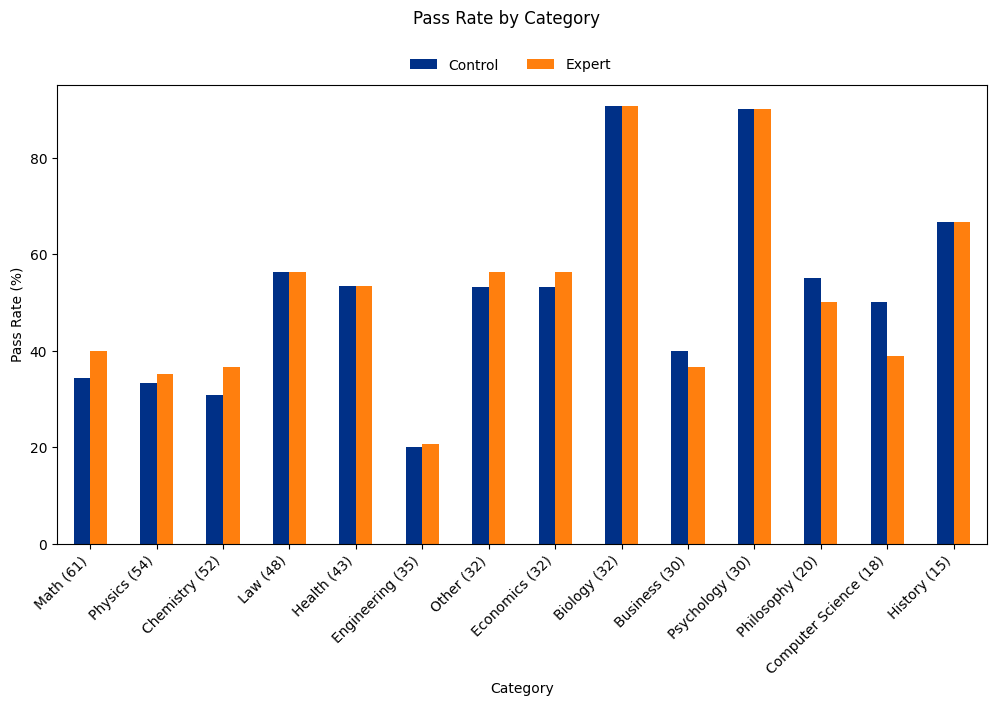

In [2]:
import matplotlib.pyplot as plt

# overall pass rate
control_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)

print(f'\nControl pass rate: {control_pass_rate}%')
print(f'Expert pass rate: {expert_pass_rate}%\n')


# pass rate by category vizz
category_counts = (
    filtered_df.groupby('category')['question']
    .nunique()
)

pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

plot_df = plot_df.rename(columns={False: 'Control', True: 'Expert'})

ordered_categories = category_counts.sort_values(ascending=False).index
plot_df = plot_df.loc[ordered_categories]

formatted_names = {
    cat: cat.replace('_', ' ').replace('-', ' ').title()
    for cat in plot_df.index
}

plot_df.index = [
    f'{formatted_names[cat]} ({int(category_counts[cat])})'
    for cat in plot_df.index
]

fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(kind='bar', ax=ax, color=['#003087', '#FF7F0E'])

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')

fig.suptitle('Pass Rate by Category', y=1)

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=len(plot_df.columns),
    frameon=False
)

plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(top=0.875)

plt.show()

## 🔬 Inferential statistics

- **Exact McNemar’s test:** this test was chosen because the same questions are answered by the LLM under two conditions (control and expert persona), each result is binary (pass or fail), the data can be arranged in a 2×2 contingency table and the disagreement counts (where a question passed under one condition but failed under another) are relatively low. McNemar's test checks whether two conditions differ in a paired setup by looking only at these disagreements. If the persona truly has no effect, these disagreements should happen roughly equally in both directions.

### Exact McNemar's test

$$p = 2 \times \sum_{i=0}^{\min(b,c)} \binom{b+c}{i} \left(0.5\right)^{b+c}$$

**Where:**

$b$ = the number of questions where the *first* condition (e.g., control) got it right and the *second* condition (expert-persona) got it wrong.

$c$ = the number of questions where the *second* condition (expert-persona) got it right and the *first* condition (control) got it wrong.

$b + c$ = the total number of disagreements.

$i$ = a stand-in number representing the number of disagreements that went in a specific direction.

> ***Note:** this is used as a part of a loop where the theoretical probability of observing a result at each value of $i$ is calculated (see more on exactly how this is done below). The loop begins at 0 and stops at the smaller of the two disagreement counts, $\min(b,c)$. This upper limit is selected because it represents outcomes as unlikely as or more than what we observed (we would normally expect a 50/50 split between $b$ or $c$ if there were really no difference between the conditions). These probabilities are then summed to give us the overall probability of observing a result as extreme as ours or more by chance alone (p-value).*

$\binom{b+c}{i}$ = out of the total disagreements, how many different ways could we have arranged exactly $i$ of those questions to favor a certain condition. The more theoretical combinations that can produce a specific outcome, the more likely it is. For example, you are more likely to roll a 7 than a 12 when using two dice because multiple combinations result in a 7 and only one a 12.

$\left(0.5\right)^{b+c}$ = the probability of any *one single, specific* sequence for $b + c$ disagreements. If the persona truly had no effect, each disagreement would have a 50/50 chance of going either way, hence the 0.5 assumption. The term above, $\binom{b+c}{i}$, is multiplied by this term to calculate the likelihood of a specific result based on the total disagreements.

> ***Note:** even when there are many potential ways of arranging $i$ questions to favour a certain condition, there will also be an exponentially larger pool of total possible arrangements if the number of total disagreements ($b + c$) is high. Using $\left(0.5\right)^{b+c}$ takes this into account and keeps the final result a valid probability rather than an ever-inflating count.* 

$\sum_{i=0}^{\min(b,c)}$ = adds up the probabilities of every outcome *at least as imbalanced* as what we actually saw in our experiment. We need this because a p-value isn't just "how likely is my exact result" — it's an answer to the question of "how likely would we be to observe a result this extreme or worse by chance alone?"

$2 \times$ = makes the test two-sided. This means it determines the likelihood that an imbalance of this magnitude could have occured in *either* direction (i.e. for all we knew, the expert persona could have helped or hindered LLM performance).

$p$ = the final probability (p-value). A small $p$ (conventionally < 0.05) means the split between $b$ and $c$ is unlikely to be due to chance alone.

#### Built-in implementation

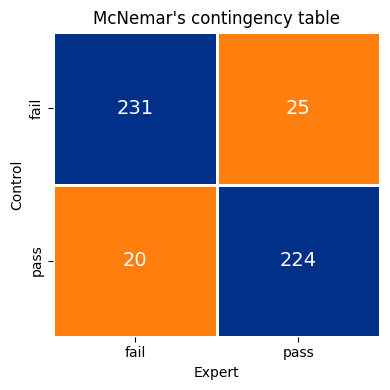


p-value: 0.5514843298025198 



In [3]:
from statsmodels.stats.contingency_tables import mcnemar
from matplotlib.colors import ListedColormap
import seaborn as sns

paired = filtered_df.pivot(
    index='question',
    columns='is_expert',
    values='result'
)

paired.columns = ['Control', 'Expert']

paired = paired.reset_index()

table = pd.crosstab(
    paired['Control'],
    paired['Expert']
)

cmap = ListedColormap([
    '#FF7F0E',
    '#003087'
])

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14},
    ax=ax
)
ax.set_xlabel('Expert')
ax.set_ylabel('Control')
ax.set_title("McNemar's contingency table")
plt.tight_layout()
plt.show()

result = mcnemar(table, exact=True)

print('\np-value:', result.pvalue, '\n')

#### Manual implementation

In [33]:
from IPython.display import display, Math


verbose = True


b = table.iloc[0, 1]
c = table.iloc[1, 0]
n = b + c


def comb(n, k):
    if k > n:
        return 0

    k = min(k, n - k)
    result = 1
    
    for i in range(1, k + 1):
            
        result = result * (n - k + i) // i
    
    return result


x = min(b, c)
p_value = 0

for k in range(x + 1):

    term = comb(n=n, k=k) * (0.5**n)
    
    if verbose: 
        display(Math(
            rf'''
                p \; = \; {{p}} \; + \; \binom{{b+c}}{{i}} \left(0.5\right)^{{b+c}}
                \; = \; {p_value} \; + \; {term}
            '''
        ))
        
    p_value += term


display(Math(
    rf'''
        p \; = \; 2 \; \times \; p
        \; = \; 2 \; \times \; {min(1, p_value)}
    '''
))
p_value = min(p_value * 2, 1)


print(f'\n\np-value: {p_value}\n')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>



p-value: 0.5514843298025198

